In [ ]:
import pandas as pd
import yfinance as yf

print("Libraries loaded successfully!")

In [ ]:
import yfinance as yf

apple = yf.download(
    "AAPL",
    start="2021-01-01",
    end="2026-01-01"
)

apple.head()

In [ ]:
apple.tail()

In [ ]:
apple = yf.download(
    "AAPL",
    start="2021-01-01"
)

In [5]:
import yfinance as yf

stocks = ["AAPL", "GOOGL", "MSFT", "AMZN", "TSLA"]

stock_data = {}

for stock in stocks:
    stock_data[stock] = yf.download(
        stock,
        start="2020-01-01"
    )

print("All stock data downloaded!")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

All stock data downloaded!


In [6]:
stock_data["AAPL"].head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333878,72.394086,71.091184,71.344054,135480400
2020-01-03,71.630623,72.389242,71.406651,71.563190,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861832,72.466315,71.642674,72.211033,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


In [7]:
stock_data["AAPL"].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1620 entries, 2020-01-02 to 2026-06-12
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1620 non-null   float64
 1   (High, AAPL)    1620 non-null   float64
 2   (Low, AAPL)     1620 non-null   float64
 3   (Open, AAPL)    1620 non-null   float64
 4   (Volume, AAPL)  1620 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 75.9 KB


In [8]:
stock_data["AAPL"].describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1620.000000,1620.000000,1620.000000,1620.000000,1.620000e+03
mean,172.005459,173.774616,170.086549,171.853525,8.199795e+07
std,55.217599,55.626504,54.802795,55.195943,5.056980e+07
min,54.163700,55.160698,51.324796,55.059309,1.791060e+07
25%,134.173847,136.149524,132.300569,134.340550,4.896942e+07
50%,168.094284,169.544397,166.584061,167.698980,6.798530e+07
75%,212.417923,214.424342,210.154577,212.216081,9.692240e+07
max,315.200012,317.399994,309.649994,314.179993,4.265100e+08


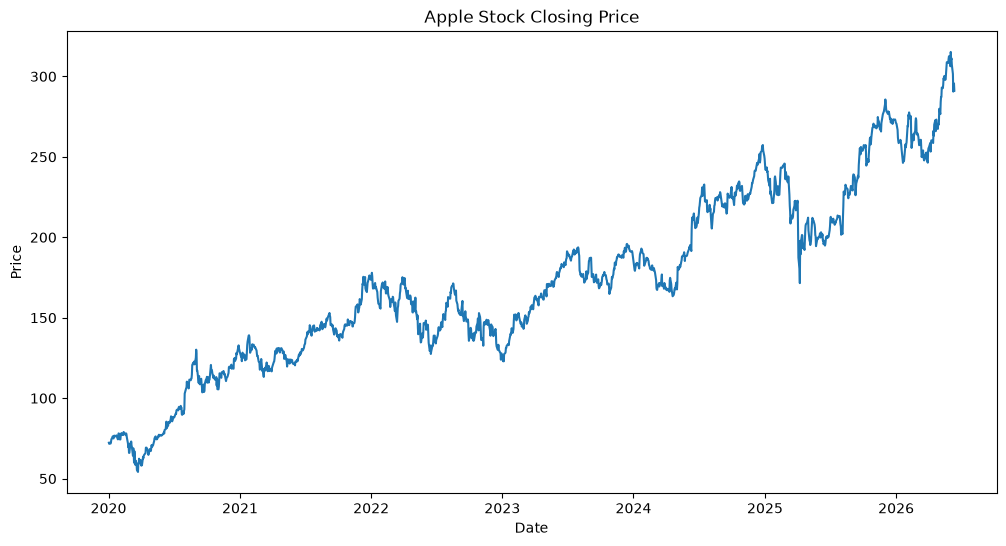

In [9]:
import matplotlib.pyplot as plt

apple = stock_data["AAPL"]

plt.figure(figsize=(12,6))

plt.plot(apple["Close"])

plt.title("Apple Stock Closing Price")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [10]:
apple = stock_data["AAPL"]

apple["MA50"] = apple["Close"].rolling(window=50).mean()

apple["MA200"] = apple["Close"].rolling(window=200).mean()

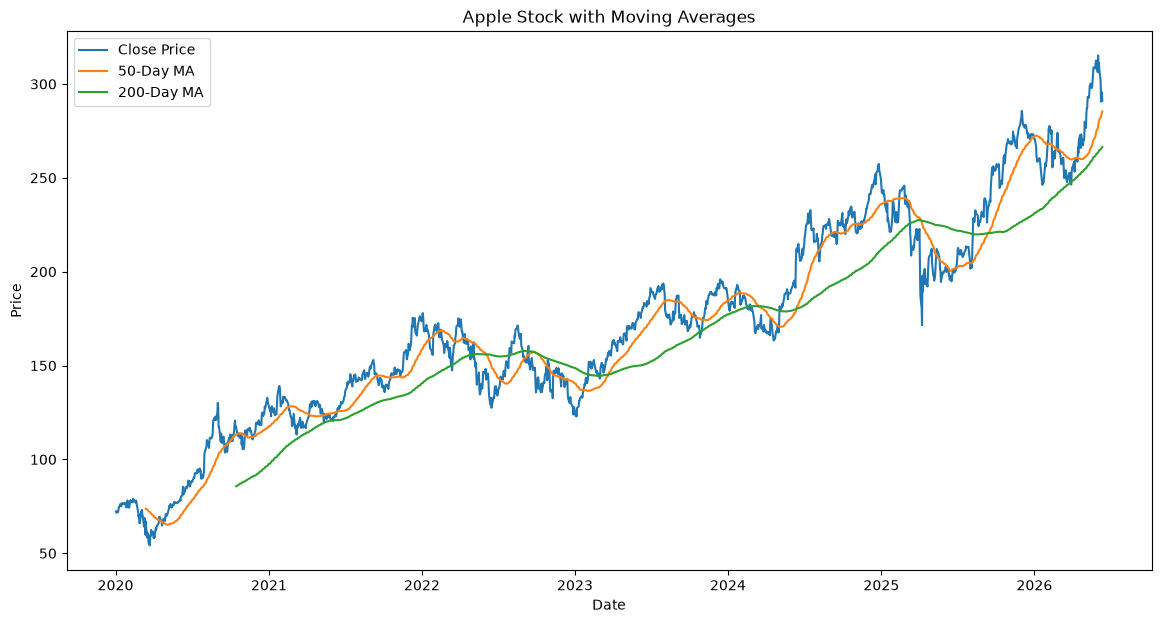

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

plt.plot(apple["Close"], label="Close Price")

plt.plot(apple["MA50"], label="50-Day MA")

plt.plot(apple["MA200"], label="200-Day MA")

plt.title("Apple Stock with Moving Averages")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.show()

In [12]:
apple["Daily_Return"] = apple["Close"].pct_change()

apple["Daily_Return"].head()

Date
2020-01-02         NaN
2020-01-03   -0.009722
2020-01-06    0.007968
2020-01-07   -0.004703
2020-01-08    0.016087
Name: Daily_Return, dtype: float64

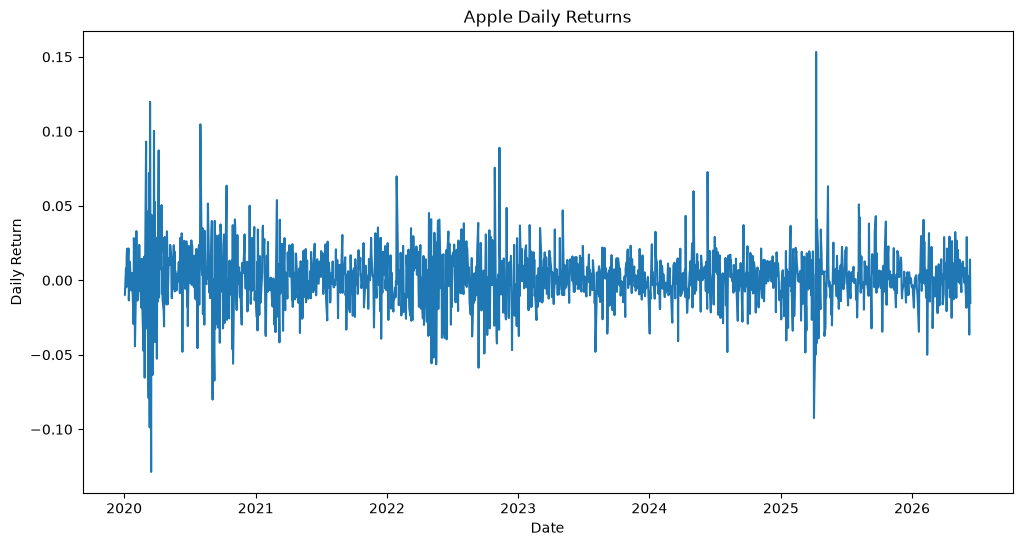

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(apple["Daily_Return"])

plt.title("Apple Daily Returns")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.show()

In [14]:
apple["Daily_Return"].std()

np.float64(0.019751023461414417)

In [15]:
apple["Daily_Return"].describe()

count    1619.000000
mean        0.001055
std         0.019751
min        -0.128647
25%        -0.008209
50%         0.001096
75%         0.011134
max         0.153288
Name: Daily_Return, dtype: float64

In [16]:
close_prices = pd.DataFrame()

for stock in stocks:
    close_prices[stock] = stock_data[stock]["Close"]

close_prices.head()

,AAPL,GOOGL,MSFT,AMZN,TSLA
Date,,,,,
2020-01-02,72.333878,67.832520,151.829529,94.900497,28.684000
2020-01-03,71.630623,67.477654,149.939011,93.748497,29.534000
2020-01-06,72.201408,69.276222,150.326523,95.143997,30.102667
2020-01-07,71.861832,69.142410,148.955917,95.343002,31.270666
2020-01-08,73.017845,69.634537,151.328552,94.598503,32.809334


In [17]:
correlation = close_prices.corr()

correlation

,AAPL,GOOGL,MSFT,AMZN,TSLA
AAPL,1.000000,0.895139,0.902811,0.773392,0.819710
GOOGL,0.895139,1.000000,0.775664,0.819533,0.786068
MSFT,0.902811,0.775664,1.000000,0.781732,0.706890
AMZN,0.773392,0.819533,0.781732,1.000000,0.721985
TSLA,0.819710,0.786068,0.706890,0.721985,1.000000


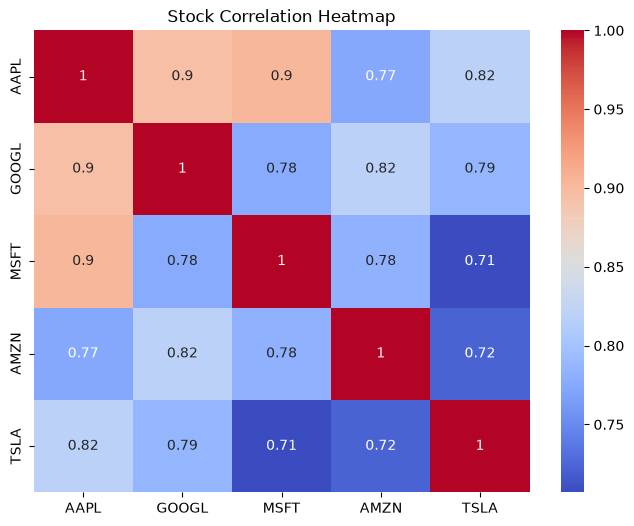

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Stock Correlation Heatmap")

plt.show()

In [19]:
for stock in stocks:
    stock_data[stock].to_csv(f"../data/{stock}.csv")

print("All files saved successfully!")

All files saved successfully!
